# Practice 12 — Fine-tuning on a New Class

A pretrained detector knows 80 classes.
The object you care about is usually not one of them.

| Question | Answer this notebook gives |
|:---|:---|
| What is fine-tuning for? | teaching a class the weights have never seen |
| How much data does it take? | a few hundred images, because the backbone is inherited |
| What changes for masks instead of boxes? | the weights file, and nothing else in the call |

The new class is `crack`, from photographs of concrete and asphalt surfaces.

---
## Step 0. Setup

`ultralytics` provides the model, the training loop and the metrics.
Setting `YOLO_VERBOSE` before the import turns off the progress bar it prints for every batch.

In [1]:
import os
import subprocess
import sys

os.environ['YOLO_VERBOSE'] = 'False'

try:
    import ultralytics
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'], check=True)
    import ultralytics

print(f'ultralytics {ultralytics.__version__}')

ultralytics 8.4.120


In [2]:
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

np.random.seed(42)
torch.manual_seed(42)

BUILD = Path('build')
DATA = Path('data')
# ultralytics needs an absolute path here, otherwise the run folder lands next to the notebook
RUNS = (BUILD / 'runs').resolve()
BUILD.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)
RUNS.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device : {device}')

device : cuda


In [3]:
crack_dir = DATA / 'crack_full'

if not crack_dir.exists():
    urllib.request.urlretrieve(
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/crack-seg.zip',
        BUILD / 'crack-seg.zip')
    # this archive has no top level folder inside, so the destination folder is named here
    with zipfile.ZipFile(BUILD / 'crack-seg.zip') as archive:
        archive.extractall(crack_dir)

for split in ['train', 'val', 'test']:
    images = sorted((crack_dir / 'images' / split).glob('*.jpg'))
    print(f'{split:5s} : {len(images)} images')

train : 3717 images
val   : 200 images
test  : 112 images


---
## Step 1. What the Pretrained Models Do Here

Both models below are the COCO weights, untouched.
`result.plot()` draws whatever the model found, in BGR order, so the channels are reversed for
matplotlib.

In [4]:
pretrained_detection_model = YOLO(str(BUILD / 'yolo11n.pt'))
pretrained_segmentation_model = YOLO(str(BUILD / 'yolo11n-seg.pt'))

print(f"'crack' among the 80 class names : {'crack' in pretrained_detection_model.names.values()}")
print()

crack_images = sorted((crack_dir / 'images' / 'test').glob('*.jpg'))[:4]
for image_path in crack_images:
    detection_result = pretrained_detection_model.predict(image_path, conf=0.25, verbose=False)[0]
    segmentation_result = pretrained_segmentation_model.predict(image_path, conf=0.25, verbose=False)[0]
    print(f'{image_path.name[:12]} : detection {len(detection_result.boxes)} objects, '
          f'segmentation {len(segmentation_result.boxes)} objects')

'crack' among the 80 class names : False



1616.rf.c868 : detection 0 objects, segmentation 0 objects
1675.rf.e3aa : detection 0 objects, segmentation 0 objects
1686.rf.809f : detection 0 objects, segmentation 0 objects
1706.rf.011d : detection 0 objects, segmentation 0 objects


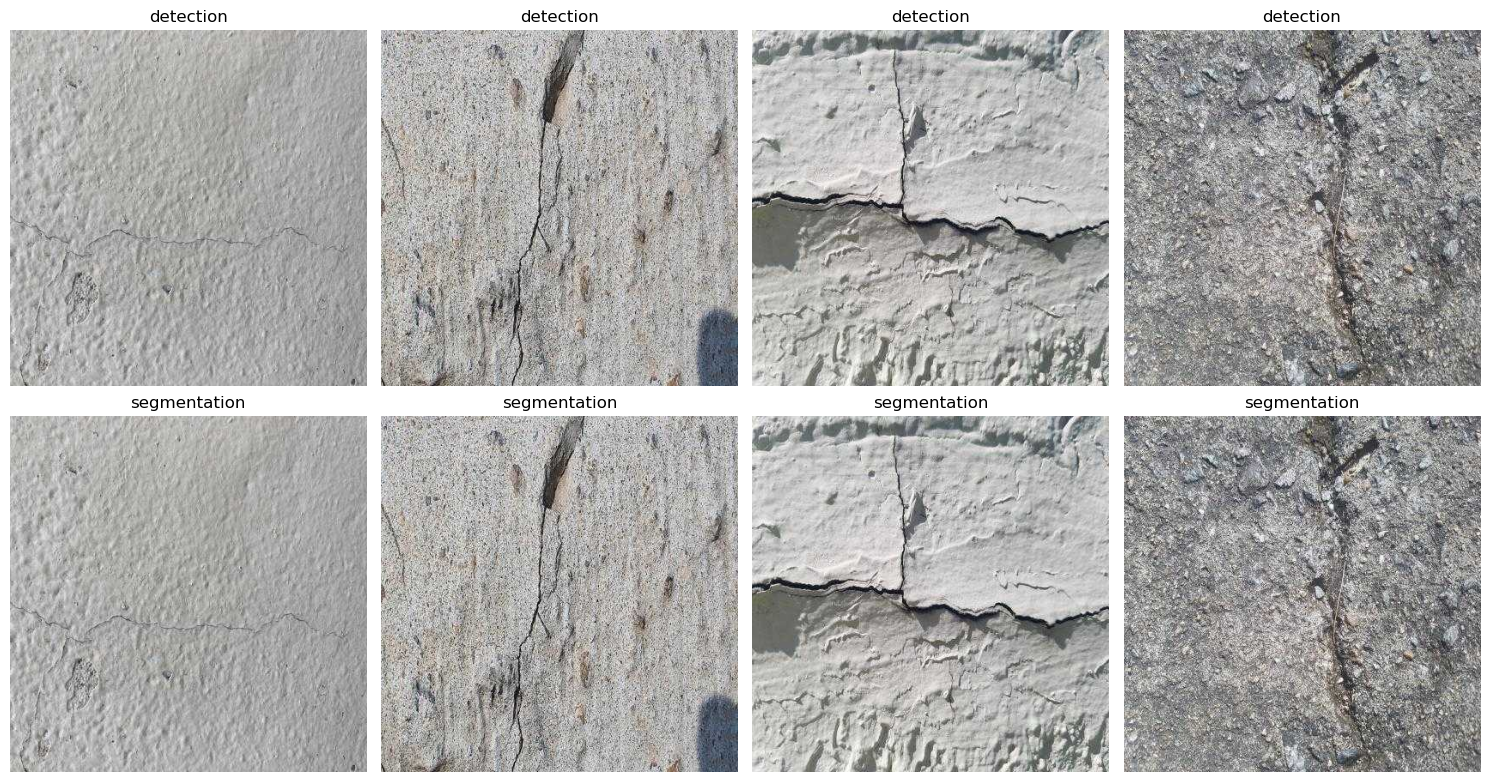

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for column, image_path in enumerate(crack_images):
    detection_result = pretrained_detection_model.predict(image_path, conf=0.25, verbose=False)[0]
    segmentation_result = pretrained_segmentation_model.predict(image_path, conf=0.25, verbose=False)[0]

    axes[0, column].imshow(detection_result.plot()[:, :, ::-1])
    axes[0, column].set_title('detection')
    axes[0, column].axis('off')

    axes[1, column].imshow(segmentation_result.plot()[:, :, ::-1])
    axes[1, column].set_title('segmentation')
    axes[1, column].axis('off')

plt.tight_layout(); plt.show()

Nothing is drawn on any of the four panels.
The weights are not broken.
Their output layer has 80 slots fixed when they were trained, and none of those slots means `crack`.

---
## Step 2. The Label Format

A YOLO dataset is two mirrored folder trees.
Every image has a label file of the same name under `labels/`.

A segmentation label line is `class x1 y1 x2 y2 ... xn yn`: an outline whose coordinates are divided by
the image size.
Its length varies with the shape, which is what separates it from a detection line of `class cx cy w h`.

In [6]:
image_path = crack_images[0]
label_path = crack_dir / 'labels' / 'test' / (image_path.stem + '.txt')
label_line = label_path.read_text().strip().split('\n')[0]

numbers = label_line.split()
print(f'class          : {numbers[0]}')
print(f'coordinates    : {len(numbers) - 1}')
print(f'outline points : {(len(numbers) - 1) // 2}')
print()
print('first 8 numbers')
print(' '.join(numbers[:9]))

class          : 0
coordinates    : 174
outline points : 87

first 8 numbers
0 0.03686995913461539 0.9808467740384615 0.03245967788461539 0.9595654110576923 0.030569555288461538 0.9517249110576922 0.03497983894230769 0.9438844086538462


Normalized numbers are hard to judge as text.
Drawing them back onto the image is the fastest check that a label file is right.

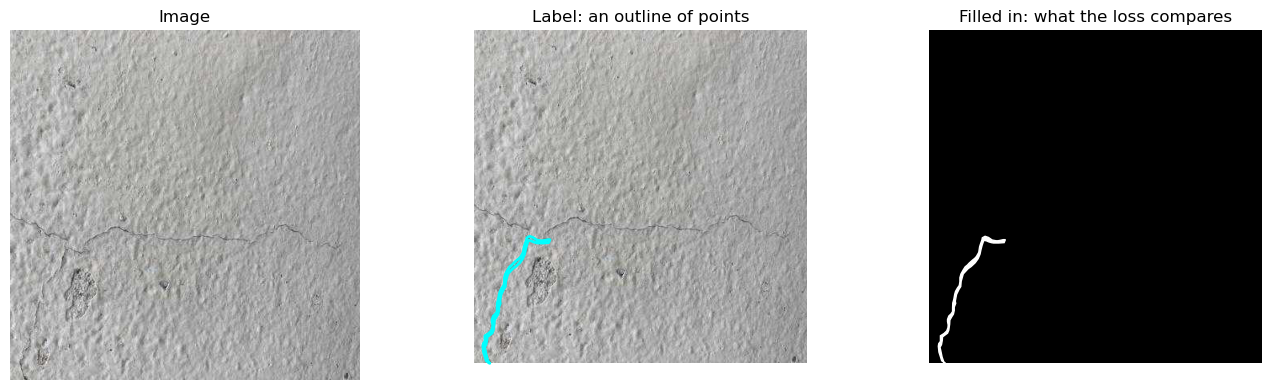

In [7]:
crack_image = np.array(Image.open(image_path).convert('RGB'))
image_height = crack_image.shape[0]
image_width = crack_image.shape[1]

# the outline, back in pixels
outline = np.array(numbers[1:], dtype=float).reshape(-1, 2)
outline_x = outline[:, 0] * image_width
outline_y = outline[:, 1] * image_height

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(crack_image)
axes[0].set_title('Image')

axes[1].imshow(crack_image)
axes[1].plot(outline_x, outline_y, color='cyan', linewidth=2)
axes[1].set_title('Label: an outline of points')

# training fills that outline in, and the loss compares this against the predicted mask
axes[2].imshow(np.zeros_like(crack_image))
axes[2].fill(outline_x, outline_y, color='white')
axes[2].set_title('Filled in: what the loss compares')

for panel_axis in axes:
    panel_axis.axis('off')

plt.tight_layout(); plt.show()

The file stores points and the loader fills them in.
A detection label is the same outline reduced to its extent, which is why one dataset trains both kinds
of model.

In [8]:
center_x = (outline_x.min() + outline_x.max()) / 2 / image_width
center_y = (outline_y.min() + outline_y.max()) / 2 / image_height
box_width = (outline_x.max() - outline_x.min()) / image_width
box_height = (outline_y.max() - outline_y.min()) / image_height

print(f'segmentation label : class 0 with {len(outline)} points')
print(f'detection label    : class 0 {center_x:.4f} {center_y:.4f} {box_width:.4f} {box_height:.4f}')

segmentation label : class 0 with 87 points
detection label    : class 0 0.1263 0.8089 0.2016 0.3819


---
## Step 3. Pointing YOLO at the Data

`data.yaml` says where the folders are and what the class indices mean.
`test` is held out from training and from checkpoint selection, so it is the split reported below.

In [9]:
crack_yaml_path = (DATA / 'crack.yaml').resolve()

with open(crack_yaml_path, 'w', encoding='utf-8') as yaml_file:
    yaml_file.write(f'path: {crack_dir.resolve().as_posix()}\n')
    yaml_file.write('train: images/train\n')
    yaml_file.write('val: images/val\n')
    yaml_file.write('test: images/test\n')
    yaml_file.write('names:\n')
    yaml_file.write('  0: crack\n')

print(crack_yaml_path.read_text().strip())

path: D:/Main/00_Research/00_Python/00_Lecture/01_AI-ME_Graduate_revised/data/crack_full
train: images/train
val: images/val
test: images/test
names:
  0: crack


In [10]:
pretrained_model = YOLO(str(BUILD / 'yolo11n.pt'))
pretrained_metrics = pretrained_model.val(data=str(crack_yaml_path), split='test', imgsz=320,
                                          project=str(RUNS), name='crack_pretrained_test', exist_ok=True)

print(f'pretrained box mAP@50 : {pretrained_metrics.box.map50:.5f}')

pretrained box mAP@50 : 0.01057


The score is not exactly zero only because a stray COCO box occasionally overlaps a crack.
Read it as the floor that training has to beat.

---
## Step 4. Fine-tuning a Detector

`fraction=0.05` trains on 5 percent of the images, which is about 185 of them and takes under a minute
on a GPU.
`patience=0` runs every epoch, and `amp=False` stops ultralytics from downloading a second model to
check mixed precision.

`val()` is called on the same object right after training, the way it would be in a script.

In [11]:
epochs = 20

detection_model = YOLO(str(BUILD / 'yolo11n.pt'))
detection_model.train(data=str(crack_yaml_path), epochs=epochs, fraction=0.05,
                      imgsz=320, batch=16, optimizer='SGD', lr0=0.01,
                      seed=42, amp=False, workers=0, patience=0,
                      project=str(RUNS), name='crack_detect', exist_ok=True)

detection_metrics = detection_model.val(data=str(crack_yaml_path), split='test', imgsz=320,
                                        project=str(RUNS), name='crack_detect_test', exist_ok=True)
print(f'fine-tuned box mAP@50 : {detection_metrics.box.map50:.5f}')

fine-tuned box mAP@50 : 0.49755


Every epoch is written to `results.csv` inside the run folder.
Reading that file is how the training becomes a picture.

   epoch  train/box_loss  val/box_loss  metrics/mAP50(B)
0      1         2.11312       1.26773           0.10176
1      2         1.54759       1.74642           0.12215
2      3         1.49509       1.81563           0.27517
3      4         1.57956       2.11935           0.16918
4      5         1.57012       1.85970           0.40242


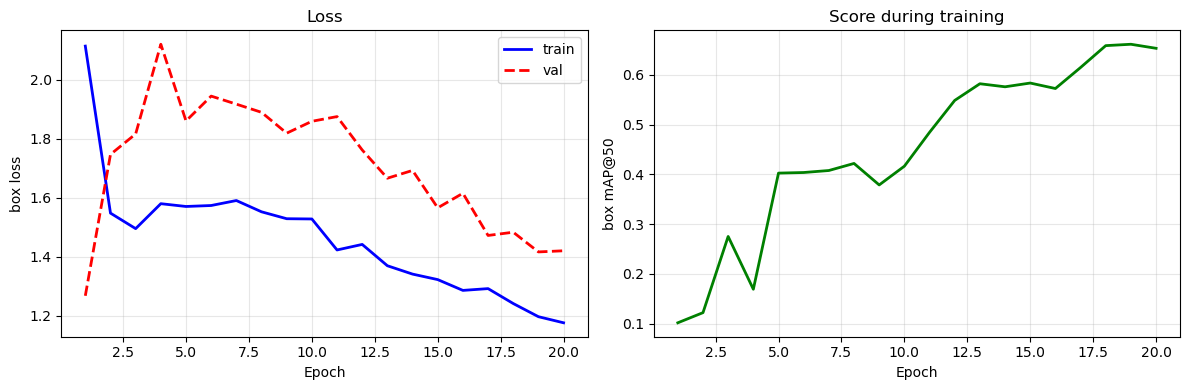

In [12]:
detection_history = pd.read_csv(RUNS / 'crack_detect' / 'results.csv')
print(detection_history[['epoch', 'train/box_loss', 'val/box_loss', 'metrics/mAP50(B)']].head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(detection_history['epoch'], detection_history['train/box_loss'], 'b-',
             linewidth=2, label='train')
axes[0].plot(detection_history['epoch'], detection_history['val/box_loss'], 'r--',
             linewidth=2, label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('box loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(detection_history['epoch'], detection_history['metrics/mAP50(B)'], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('box mAP@50')
axes[1].set_title('Score during training'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

The score climbs in the first few epochs and then flattens, which is where 20 epochs comes from.
The validation loss stops falling before the training loss does, the usual sign that more epochs would
fit these images rather than cracks in general.

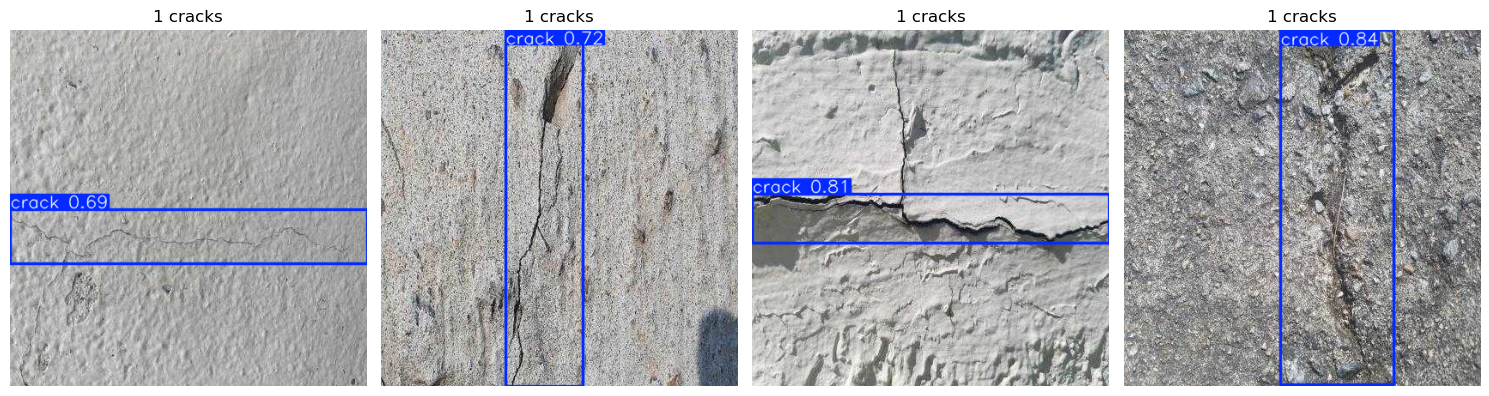

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for panel_axis, image_path in zip(axes, crack_images):
    result = detection_model.predict(image_path, conf=0.25, verbose=False)[0]
    panel_axis.imshow(result.plot()[:, :, ::-1])
    panel_axis.set_title(f'{len(result.boxes)} cracks')
    panel_axis.axis('off')

plt.tight_layout(); plt.show()

These are test images, which no training step and no checkpoint choice ever read.
A box that covers most of the frame is not a mistake: the crack runs across the frame.

---
## Step 5. Why the Pretrained Weights Matter

The run below changes one thing: the weights start from random numbers instead of the COCO ones.

| Item | A: pretrained | B: fine-tuned | C: from scratch |
|:---|:---|:---|:---|
| **initial weights** | **COCO** | **COCO** | **random** |
| **training** | **none** | **20 epochs** | **20 epochs** |
| data, `fraction`, `imgsz`, `batch`, `lr0`, `seed` | same | same | same |

A against B isolates the training; B against C isolates the starting weights.

In [14]:
# building the model from its yaml means no pretrained weights are loaded
scratch_model = YOLO('yolo11n.yaml')
scratch_model.train(data=str(crack_yaml_path), epochs=epochs, fraction=0.05,
                    imgsz=320, batch=16, optimizer='SGD', lr0=0.01,
                    seed=42, amp=False, workers=0, patience=0,
                    project=str(RUNS), name='crack_scratch', exist_ok=True)

scratch_metrics = scratch_model.val(data=str(crack_yaml_path), split='test', imgsz=320,
                                    project=str(RUNS), name='crack_scratch_test', exist_ok=True)

print('                  box mAP@50')
print(f'A pretrained     {pretrained_metrics.box.map50:11.5f}')
print(f'B fine-tuned     {detection_metrics.box.map50:11.5f}')
print(f'C from scratch   {scratch_metrics.box.map50:11.5f}')

                  box mAP@50
A pretrained         0.01057
B fine-tuned         0.49755
C from scratch       0.00388


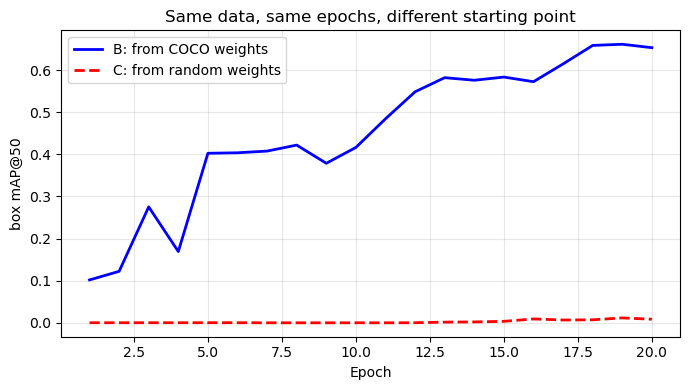

In [15]:
scratch_history = pd.read_csv(RUNS / 'crack_scratch' / 'results.csv')

plt.figure(figsize=(7, 4))
plt.plot(detection_history['epoch'], detection_history['metrics/mAP50(B)'], 'b-',
         linewidth=2, label='B: from COCO weights')
plt.plot(scratch_history['epoch'], scratch_history['metrics/mAP50(B)'], 'r--',
         linewidth=2, label='C: from random weights')
plt.xlabel('Epoch'); plt.ylabel('box mAP@50')
plt.title('Same data, same epochs, different starting point')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

C never leaves the bottom of the plot.
It had the same images, the same epochs and the same learning rate, but no backbone that already knew
edges and textures.
A few hundred images are enough to name a new class, not to learn vision from nothing.

---
## Step 6. The Same Training, With Masks

`yolo11n-seg.pt` replaces `yolo11n.pt` and nothing else in the call changes.
The dataset is the one already on disk, since its labels were outlines all along.

Validation now reports two families of numbers: one for boxes, one for masks.

In [16]:
segmentation_model = YOLO(str(BUILD / 'yolo11n-seg.pt'))
segmentation_model.train(data=str(crack_yaml_path), epochs=epochs, fraction=0.05,
                         imgsz=320, batch=16, optimizer='SGD', lr0=0.01,
                         seed=42, amp=False, workers=0, patience=0,
                         project=str(RUNS), name='crack_segment', exist_ok=True)

segmentation_metrics = segmentation_model.val(data=str(crack_yaml_path), split='test', imgsz=320,
                                              project=str(RUNS), name='crack_segment_test',
                                              exist_ok=True)

print(f'box  mAP@50 : {segmentation_metrics.box.map50:.5f}')
print(f'mask mAP@50 : {segmentation_metrics.seg.map50:.5f}')

box  mAP@50 : 0.46162
mask mAP@50 : 0.37393


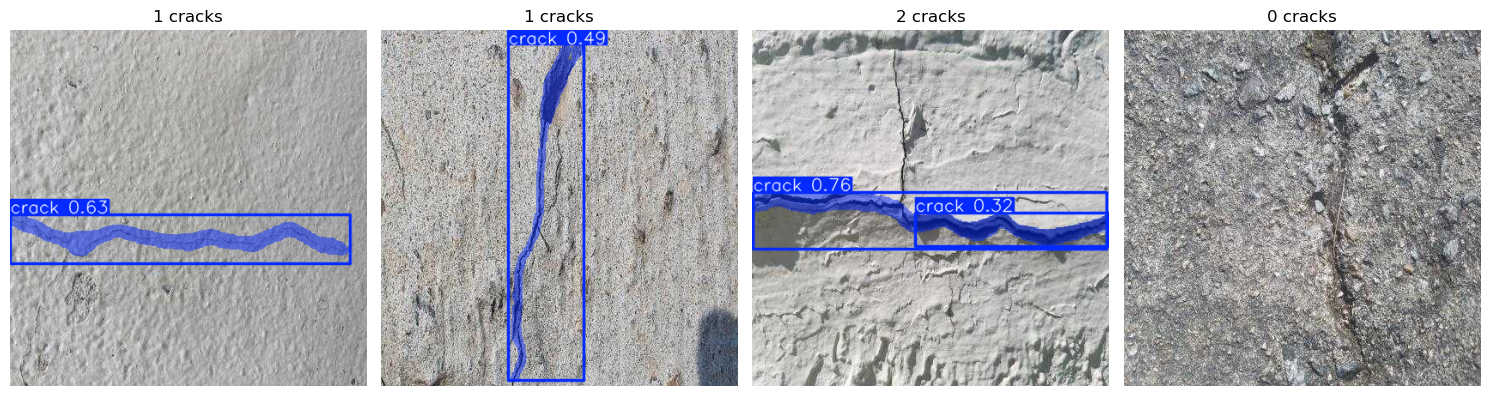

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for panel_axis, image_path in zip(axes, crack_images):
    result = segmentation_model.predict(image_path, conf=0.25, verbose=False)[0]
    panel_axis.imshow(result.plot()[:, :, ::-1])
    panel_axis.set_title(f'{len(result.boxes)} cracks')
    panel_axis.axis('off')

plt.tight_layout(); plt.show()

The box score lands close to the detector's, from the same data and the same schedule.
The mask score sits below it, because an outline has to be right pixel by pixel while a box only has to
be right at its four edges.

This model does **instance** segmentation, one mask per object, and the count is part of its answer.

| Task | One output covers |
|:---|:---|
| Semantic segmentation | every pixel of a class, as a single region |
| Instance segmentation | every pixel of one object, one mask per object |

For a crack the two are close, because a branching crack is one connected shape and the split into
instances is a decision the labels made rather than a physical fact.

---
## Step 7. Why a Mask and Not a Box

A crack runs diagonally across its own bounding box.
`retina_masks=True` returns each mask at the size of the original image, so its pixels can be counted
against the area of the box.

In [18]:
print('image          mask pixels   box pixels   fill')
for image_path in crack_images:
    result = segmentation_model.predict(image_path, conf=0.25, retina_masks=True, verbose=False)[0]
    for index in range(len(result.boxes)):
        x1, y1, x2, y2 = result.boxes.xyxy[index]
        box_pixels = float((x2 - x1) * (y2 - y1))
        mask_pixels = float(result.masks.data[index].sum())
        print(f'{image_path.name[:12]} {mask_pixels:12.0f} {box_pixels:12.0f}   '
              f'{mask_pixels / box_pixels:.3f}')

image          mask pixels   box pixels   fill
1616.rf.c868         7394        22478   0.329
1675.rf.e3aa         5429        35890   0.151
1686.rf.809f         8293        26984   0.307
1686.rf.809f         3741         8711   0.429


A fraction of each box is crack and the rest is surface.
Any quantity that scales with the damage, such as area or length, has to be read from the mask.

---
## Summary

- Fine-tuning taught the weights a class they could not name before, and the score on the held-out test
  split moved from the floor to a usable number.
- The run from random weights, given the same data and the same epochs, stayed at the floor.
- Swapping the weights file turned the same call into a segmentation run, and the crack fills a small
  part of its own box.

---
## Exercises

1. Change `fraction` to 0.02 and rerun Step 4.
   How much of the score survives on a fifth of the images?
2. Change `epochs` to 5.
   All three training calls read that variable, so they shorten together.
3. Predict with `conf=0.05` on the four test images.
   Which extra cracks appear?

In [19]:
# Write your code here